# UNet Autoencoder → Feature Extraction → PCA → Clustering → Evaluation

**Pipeline**
1. Train UNet autoencoder with MSE loss
2. Extract bottleneck features from trained UNet
3. Reduce dimensionality with PCA(32) + MinMaxScaler
4. Cluster with KMeans on normalized PCA features
5. Evaluate clusters vs style/artist labels (ARI, NMI, Purity)
6. Visualize clusters with UMAP 2D

## 0. Imports and Setup

In [1]:
import os
from pathlib import Path
import time
from contextlib import nullcontext
import json
from datasets import Dataset as HFDataset
from PIL import Image
import io
from umap import UMAP

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.transforms as T

from datasets import load_dataset, Image as HFImage
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

Device: cuda


## 1. Load Local Parquet Dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set data directory to your Drive location
os.environ["DATA_DIR"] = "/content/drive/MyDrive/UN//dataWikiArt"

Mounted at /content/drive


In [3]:
DATA_DIR = Path(os.getenv("DATA_DIR", "../../dataset1/data")).resolve()
print("Data dir:", DATA_DIR)

files = sorted(str(p) for p in DATA_DIR.rglob("*.parquet"))
print("Found parquet files:", len(files))
if not files:
    raise SystemExit("No .parquet files found under ./dataset1/data. Upload/mount your data there.")

# Persist dataset splits to disk for faster reloading
ARTIFACTS_DIR = Path("artifacts"); ARTIFACTS_DIR.mkdir(exist_ok=True)
TRAIN_DS_PATH = ARTIFACTS_DIR / "train_ds"
VAL_DS_PATH = ARTIFACTS_DIR / "val_ds"
TEST_DS_PATH = ARTIFACTS_DIR / "test_ds"

if TRAIN_DS_PATH.exists() and VAL_DS_PATH.exists() and TEST_DS_PATH.exists():
    print("Loading existing dataset splits from disk...")
    train_ds = HFDataset.load_from_disk(TRAIN_DS_PATH)
    val_ds = HFDataset.load_from_disk(VAL_DS_PATH)
    test_ds = HFDataset.load_from_disk(TEST_DS_PATH)
else:
    print("Loading dataset from local parquet and creating new splits...")
    ds_full = load_dataset("parquet", data_files=files, split="train").cast_column("image", HFImage())
    print("Total records:", len(ds_full))
    print("Columns:", ds_full.column_names)

    # Persist split indices so future runs reuse the same split
    SPLITS_PATH = ARTIFACTS_DIR / "dataset_splits.json"

    if SPLITS_PATH.exists():
        print("Loading existing split indices...")
        split_indices = json.loads(SPLITS_PATH.read_text())
    else:
        print("Creating new 80/10/10 split (stratified by 'style' if available)...")
        ds_full = ds_full.add_column("idx", list(range(len(ds_full))))
        try:
            s1 = ds_full.train_test_split(test_size=0.20, stratify_by_column="style", seed=42)
            s2 = s1["test"].train_test_split(test_size=0.50, stratify_by_column="style", seed=42)
        except Exception as e:
            print("Stratified split failed, falling back to random split:", e)
            s1 = ds_full.train_test_split(test_size=0.20, seed=42)
            s2 = s1["test"].train_test_split(test_size=0.50, seed=42)

        train_ds_temp, val_ds_temp, test_ds_temp = s1["train"], s2["train"], s2["test"]
        split_indices = {
            "train": list(train_ds_temp["idx"]),
            "val": list(val_ds_temp["idx"]),
            "test": list(test_ds_temp["idx"]),
        }
        SPLITS_PATH.write_text(json.dumps(split_indices))
        print("Saved split indices to", SPLITS_PATH)

    # Rebuild splits from indices
    train_ds = ds_full.select(split_indices["train"])
    val_ds   = ds_full.select(split_indices["val"])
    test_ds  = ds_full.select(split_indices["test"])

    # Save splits to disk
    train_ds.save_to_disk(TRAIN_DS_PATH)
    val_ds.save_to_disk(VAL_DS_PATH)
    test_ds.save_to_disk(TEST_DS_PATH)
    print(f"Saved dataset splits to {ARTIFACTS_DIR}")

print(f"Train={len(train_ds)} Val={len(val_ds)} Test={len(test_ds)}")

Data dir: /content/drive/MyDrive/UN/dataWikiArt
Found parquet files: 7
Loading dataset from local parquet and creating new splits...


Generating train split: 0 examples [00:00, ? examples/s]

Total records: 103250
Columns: ['title', 'artist', 'date', 'genre', 'style', 'description', 'filename', 'image', 'embeddings_pca512', 'resnet50_non_robust_feats', 'resnet50_robust_feats']
Creating new 80/10/10 split (stratified by 'style' if available)...
Stratified split failed, falling back to random split: Stratifying by column is only supported for ClassLabel column, and column style is Value.
Saved split indices to artifacts/dataset_splits.json


Saving the dataset (0/6 shards):   0%|          | 0/82600 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10325 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10325 [00:00<?, ? examples/s]

Saved dataset splits to artifacts
Train=82600 Val=10325 Test=10325


In [ ]:
train_ds['image'][0]

## 2. Transforms and Dataset Wrapper

In [5]:
IMG_SIZE   = int(os.getenv("IMG_SIZE", "128"))
LATENT_DIM = int(os.getenv("LATENT_DIM", "128"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "64" if torch.cuda.is_available() else "32"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))

USE_FRACTION = float(os.getenv("USE_FRACTION", "0.10"))

if "full_train_ds" not in globals():
    full_train_ds = train_ds
    full_val_ds   = val_ds
    full_test_ds  = test_ds

def apply_fraction(base_ds, frac):
    if 0 < frac < 1.0:
        n = max(1, int(frac * len(base_ds)))
        return base_ds.select(range(n))
    return base_ds

train_ds = apply_fraction(full_train_ds, USE_FRACTION)
val_ds   = apply_fraction(full_val_ds, USE_FRACTION)
test_ds  = apply_fraction(full_test_ds, USE_FRACTION)

print(f"[FRACTION {USE_FRACTION*100:.0f}%] train={len(train_ds)} val={len(val_ds)} test={len(test_ds)} (full={len(full_train_ds)}/{len(full_val_ds)}/{len(full_test_ds)})")

# Transforms
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

class WikiArtDataset(TorchDataset):
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        row = self.ds[int(idx)]
        img = row["image"]
        if isinstance(img, dict):
            if "bytes" in img: img = Image.open(io.BytesIO(img["bytes"]))
            elif "path" in img: img = Image.open(img["path"])
        if img.mode != "RGB": img = img.convert("RGB")
        if self.transform: img = self.transform(img)
        return img, row.get("style", "unknown"), row.get("artist", "unknown")

pin_mem = torch.cuda.is_available()
train_loader = DataLoader(WikiArtDataset(train_ds, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)
val_loader   = DataLoader(WikiArtDataset(val_ds, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)
test_loader  = DataLoader(WikiArtDataset(test_ds, transform=transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin_mem)

print(f"Batches -> train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}")

[FRACTION 10%] train=8260 val=1032 test=1032 (full=82600/10325/10325)
Batches -> train:130 val:17 test:17


## 3. Autoencoder Definition (CNN)

In [ ]:
from autoencoder import UNetLightning

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNetLightning(
    lr=1e-4,
    in_channels=3,
    out_channels=3,
    base_ch=16,
    use_dropout=False
).to(device)

mse = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()

## 4. Autoencoder Training

In [11]:
EPOCHS = int(os.getenv("EPOCHS", "10"))
best_val = float("inf")
BEST_PATH = ARTIFACTS_DIR / "unet_best.pth"
LAST_PATH = ARTIFACTS_DIR / "unet_last.pth"

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0

    for imgs, _, _ in tqdm(train_loader, desc=f"Train {epoch}/{EPOCHS}", ncols=100):
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with amp_ctx:
            recon = model(imgs)
            loss = mse(recon, imgs)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        train_loss += loss.item() * imgs.size(0)

    train_loss /= max(1, len(train_loader.dataset))

    # Walidacja
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _, _ in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            recon = model(imgs)
            vloss = mse(recon, imgs)
            val_loss += vloss.item() * imgs.size(0)
    val_loss /= max(1, len(val_loader.dataset))

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), BEST_PATH)
        print(f"[BEST] -> {BEST_PATH}")

    dt = time.time() - t0
    print(f"Epoch {epoch}/{EPOCHS} | train={train_loss:.6f} | val={val_loss:.6f} | time={dt/60:.2f}m")

torch.save(model.state_dict(), LAST_PATH)
print("Saved last weights ->", LAST_PATH.resolve())

Train 1/10: 100%|█████████████████████████████████████████████████| 130/130 [01:37<00:00,  1.33it/s]


[BEST] -> artifacts/unet_best.pth
Epoch 1/10 | train=0.293439 | val=0.100977 | time=1.72m


Train 2/10: 100%|█████████████████████████████████████████████████| 130/130 [00:35<00:00,  3.65it/s]


[BEST] -> artifacts/unet_best.pth
Epoch 2/10 | train=0.058882 | val=0.038313 | time=0.68m


Train 3/10: 100%|█████████████████████████████████████████████████| 130/130 [00:33<00:00,  3.93it/s]


...

[BEST] -> artifacts/unet_best.pth
Epoch 8/10 | train=0.010060 | val=0.007692 | time=0.64m


Train 9/10: 100%|█████████████████████████████████████████████████| 130/130 [00:33<00:00,  3.90it/s]


[BEST] -> artifacts/unet_best.pth
Epoch 9/10 | train=0.009016 | val=0.006919 | time=0.64m


Train 10/10: 100%|████████████████████████████████████████████████| 130/130 [00:33<00:00,  3.90it/s]


[BEST] -> artifacts/unet_best.pth
Epoch 10/10 | train=0.008351 | val=0.005842 | time=0.62m
Saved last weights -> /content/artifacts/unet_last.pth


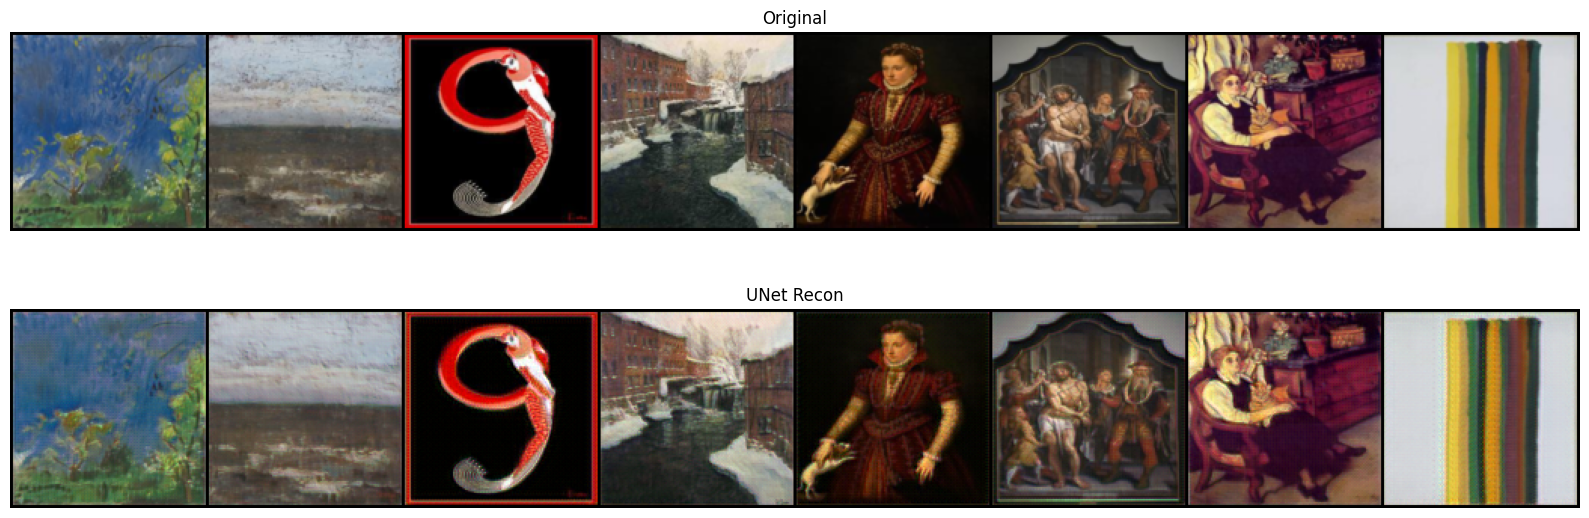

Saved reconstruction plot to: /content/artifacts/unet_recons.png


In [12]:
import torchvision.utils as vutils

def denormalize(t):
    return (t * 0.5) + 0.5

model.eval()
with torch.no_grad():
    imgs_batch, _, _ = next(iter(val_loader))
    imgs_batch = imgs_batch.to(device, non_blocking=True)
    recon_batch = model(imgs_batch)

orig = denormalize(imgs_batch.cpu()).clamp(0, 1)
recon = denormalize(recon_batch.cpu()).clamp(0, 1)

N = min(8, orig.size(0))
orig_grid = vutils.make_grid(orig[:N], nrow=N, normalize=False)
recon_grid = vutils.make_grid(recon[:N], nrow=N, normalize=False)

plt.figure(figsize=(16, 6))
plt.subplot(2,1,1); plt.imshow(np.transpose(orig_grid.numpy(), (1,2,0))); plt.axis("off"); plt.title("Original")
plt.subplot(2,1,2); plt.imshow(np.transpose(recon_grid.numpy(), (1,2,0))); plt.axis("off"); plt.title("UNet Recon")
plt.tight_layout()
plot_path = ARTIFACTS_DIR / "unet_recons.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved reconstruction plot to:", plot_path.resolve())

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from joblib import dump

model.eval()
features, styles_list, artists_list = [], [], []

with torch.no_grad():
    for imgs, styles, artists in tqdm(train_loader, desc="Extract features", ncols=100):
        imgs = imgs.to(device, non_blocking=True)
        z = model.model.encode(imgs)          # [B, LATENT_DIM]
        feats = z.detach().cpu().numpy()      # -> numpy
        features.append(feats)
        styles_list.extend(styles)
        artists_list.extend(artists)

features = np.concatenate(features, axis=0)
print("Raw bottleneck features:", features.shape)

# PCA -> 32D
pca = PCA(n_components=32, random_state=42)
features_32 = pca.fit_transform(features)
print("PCA(32) features:", features_32.shape)

# Scaler [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
features_norm = scaler.fit_transform(features_32)
print("Normalized features:", features_norm.shape)

MODELS_DIR = Path("models"); MODELS_DIR.mkdir(exist_ok=True)
dump(pca, MODELS_DIR / "pca_model.joblib")
dump(scaler, MODELS_DIR / "scaler_model.joblib")
np.savez(ARTIFACTS_DIR / "features_bottleneck_pca32.npz", features=features_norm, styles=np.array(styles_list), artists=np.array(artists_list))
print("Saved PCA+Scaler+features.")

Extract features: 100%|███████████████████████████████████████████| 130/130 [00:33<00:00,  3.86it/s]


Raw bottleneck features: (8260, 16384)
PCA(32) features: (8260, 32)
Normalized features: (8260, 32)
Saved PCA+Scaler+features.


## 6. Feature Extraction + PCA + Scaler

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from collections import Counter
from joblib import dump

data = np.load(ARTIFACTS_DIR / "features_bottleneck_pca32.npz", allow_pickle=True)
X = data["features"]
styles_arr = data["styles"]
artists_arr = data["artists"]

k = len(set(styles_arr))
print(f"Unique styles: {k}")

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)
dump(kmeans, MODELS_DIR / "kmeans_model.pkl")
print(f"Cluster counts: {Counter(cluster_labels)}")

def purity_score(pred_clusters, true_labels):
    from collections import defaultdict
    groups = defaultdict(list)
    for c, t in zip(pred_clusters, true_labels):
        groups[int(c)].append(t)
    total = len(true_labels)
    correct = sum(Counter(v).most_common(1)[0][1] for v in groups.values())
    return correct / max(total, 1)

ari_style = adjusted_rand_score(styles_arr, cluster_labels)
nmi_style = normalized_mutual_info_score(styles_arr, cluster_labels)
pur_style = purity_score(cluster_labels, styles_arr)

ari_artist = adjusted_rand_score(artists_arr, cluster_labels)
nmi_artist = normalized_mutual_info_score(artists_arr, cluster_labels)
pur_artist = purity_score(cluster_labels, artists_arr)

print("\n=== STYLE ===")
print(f"ARI: {ari_style:.4f}")
print(f"NMI: {nmi_style:.4f}")
print(f"Purity: {pur_style:.4f}")

print("\n=== ARTIST ===")
print(f"ARI: {ari_artist:.4f}")
print(f"NMI: {nmi_artist:.4f}")
print(f"Purity: {pur_artist:.4f}")

with open(ARTIFACTS_DIR / "clustering_metrics_unet.txt", "w", encoding="utf-8") as f:
    f.write("=== STYLE ===\n")
    f.write(f"ARI: {ari_style:.6f}\n")
    f.write(f"NMI: {nmi_style:.6f}\n")
    f.write(f"Purity: {pur_style:.6f}\n\n")
    f.write("=== ARTIST ===\n")
    f.write(f"ARI: {ari_artist:.6f}\n")
    f.write(f"NMI: {nmi_artist:.6f}\n")
    f.write(f"Purity: {pur_artist:.6f}\n")
print("Saved clustering metrics.")

Unique styles: 122
Cluster counts: Counter({np.int32(117): 777, np.int32(105): 770, np.int32(14): 676, np.int32(13): 461, np.int32(10): 427, np.int32(64): 427, np.int32(9): 403, np.int32(32): 351, np.int32(2): 329, np.int32(24): 319, np.int32(12): 315, np.int32(102): 313, np.int32(18): 308, np.int32(107): 282, np.int32(25): 277, np.int32(33): 276, np.int32(1): 148, np.int32(0): 145, np.int32(110): 121, np.int32(7): 111, np.int32(69): 49, np.int32(51): 45, np.int32(88): 45, np.int32(27): 44, np.int32(11): 43, np.int32(31): 43, np.int32(59): 40, np.int32(45): 39, np.int32(29): 37, np.int32(37): 36, np.int32(118): 36, np.int32(50): 30, np.int32(38): 28, np.int32(8): 28, np.int32(80): 25, np.int32(90): 24, np.int32(28): 24, np.int32(52): 22, np.int32(116): 22, np.int32(15): 21, np.int32(20): 21, np.int32(6): 21, np.int32(63): 19, np.int32(92): 19, np.int32(53): 18, np.int32(97): 15, np.int32(49): 15, np.int32(46): 14, np.int32(60): 14, np.int32(19): 12, np.int32(17): 10, np.int32(83): 9, n

## 8. UMAP 2D Visualization

Running UMAP 2D for viz ...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


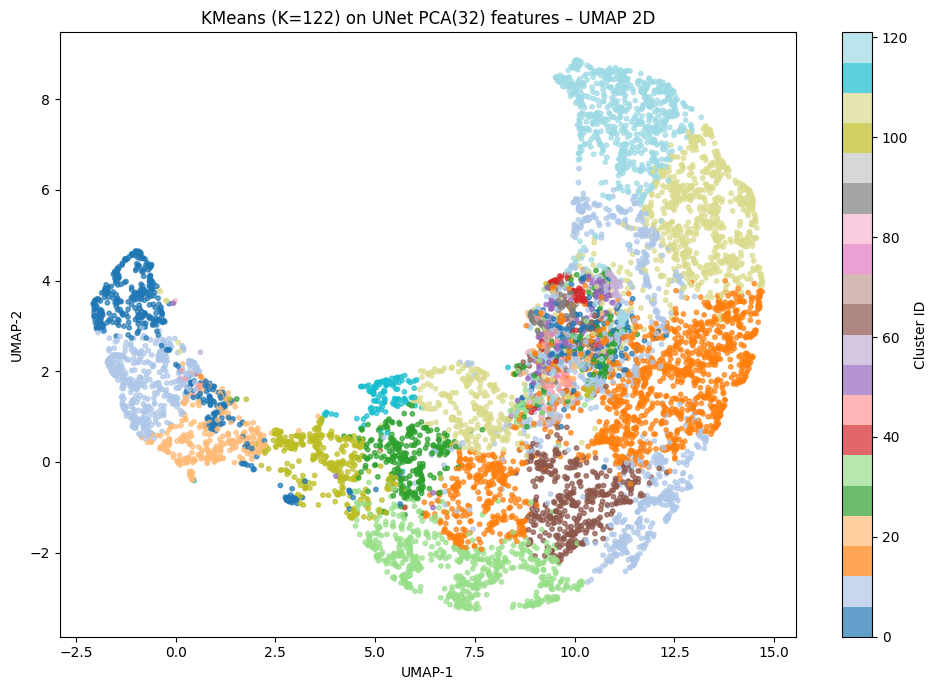

Plot saved: /content/artifacts/clusters_unet_umap2d.png


In [ ]:
from umap import UMAP

print("Running UMAP 2D for viz")
umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
emb_2d = umap_2d.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=cluster_labels, cmap='tab20', s=10, alpha=0.7)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"KMeans (K={k}) on UNet PCA(32) features – UMAP 2D")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plot_path = ARTIFACTS_DIR / "clusters_unet_umap2d.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Plot saved:", plot_path.resolve())

np.savez(ARTIFACTS_DIR / "unet_embeddings_viz.npz",
         features_pca32=X,
         umap_2d=emb_2d,
         cluster_labels=cluster_labels)